# Visualization

Paths for GAEZ data of potential yields for 3 most common pre-Columbian crops:
* Rice (Dryland).
* Rice (Wetland).
* Wheat.

We assume Rain-fed and low input level of management to fit the pre-modern agricutural conditions better.

## Visualizing Potential Yields of 3 Crops

In [56]:
# Your file paths
files = {
    'rice_dry': './DATA_GAEZ-V5_MAPSET_RES02-YLD_GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.RICD.LRLM.tif',
    'rice_wet': './DATA_GAEZ-V5_MAPSET_RES02-YLD_GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.RICW.LRLM.tif',
    'wheat': './DATA_GAEZ-V5_MAPSET_RES02-YLD_GAEZ-V5.RES02-YLD.HP0120.AGERA5.HIST.WHEA.LRLM.tif',
}

# check if files exist
import os
for crop, path in files.items():
    if not os.path.isfile(path):
        print(f"File for {crop} not found at path: {path}")
        # output current working directory
        print(f"Current working directory: {os.getcwd()}")

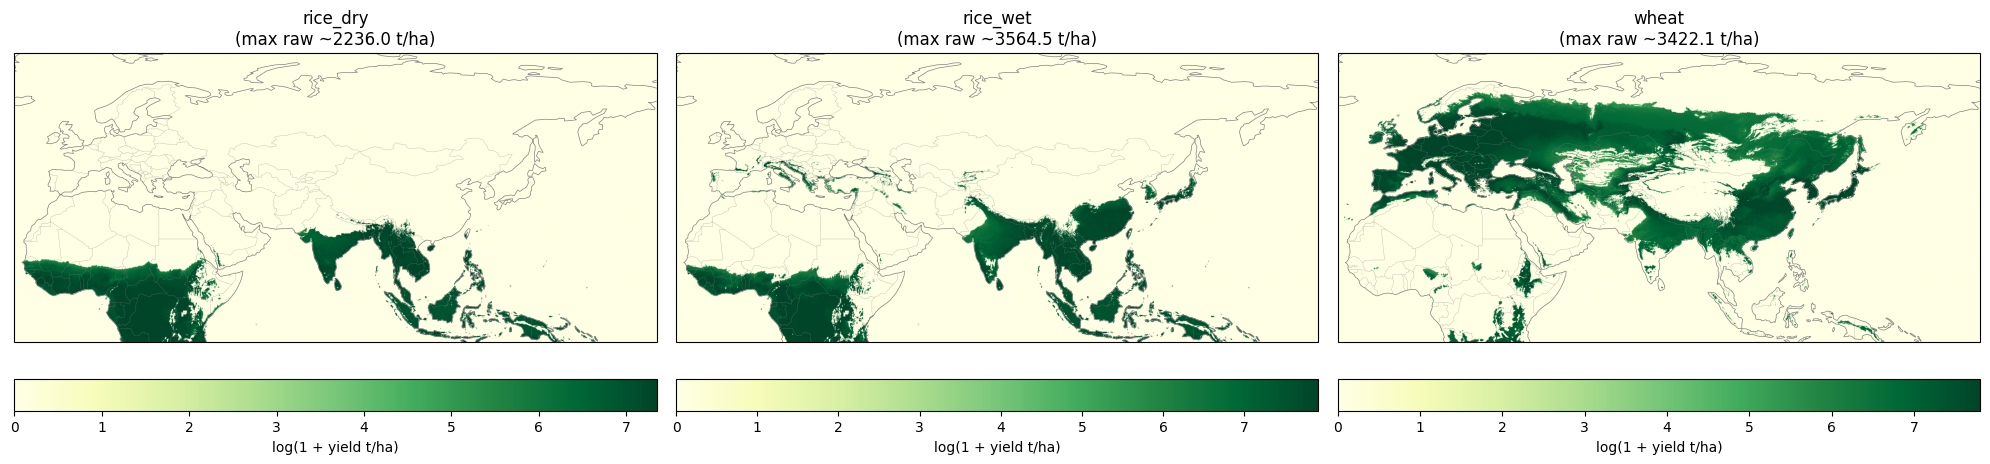

In [57]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(20, 8))
axes = []
for i, (title, filepath) in enumerate(files.items(), 1):
    with rasterio.open(filepath) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        valid_mask = (data != nodata) & ~np.isnan(data)
        data_masked = np.ma.masked_where(~valid_mask, data)
                
        data_display = np.copy(data_masked)
        data_display[data_display < 0.1] = 0  
        
        data_log = np.log1p(data_display)  # use log scale to improve visibility of low yields, while still showing high yields without saturation
        
        # Create axes with PlateCarree projection (good for global)
        ax = fig.add_subplot(1, 3, i, projection=ccrs.PlateCarree())
        axes.append(ax)
        
        im = ax.imshow(data_log,
                       origin='upper',
                       extent=(src.bounds.left, src.bounds.right,
                               src.bounds.bottom, src.bounds.top),
                       transform=ccrs.PlateCarree(),
                       cmap='YlGn',          # classic yield: yellow low → green high
                       vmin=0,
                       vmax=np.nanpercentile(data_log, 99))
        
        ax.add_feature(cfeature.COASTLINE, lw=0.5, edgecolor='gray')
        ax.add_feature(cfeature.BORDERS, lw=0.3, edgecolor='gray', alpha=0.5)
        ax.set_title(title + f"\n(max raw ~{np.nanmax(data_display):.1f} t/ha)")
        
        fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05,
                     label='log(1 + yield t/ha)')

# focus on Eurasia for Fractured-Land
for ax in axes:
    ax.set_extent([-20, 180, -10, 80], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

## Visualize the Max Calorie Production for each Pixel

We will use the crop with max calorie production as the representing crop at a pixel before rasterization.

We plot the dominant (i.e., with max `calorie*production`) crop for each pixel on the map, then compute and visualize the max possible calorie production for each pixel.

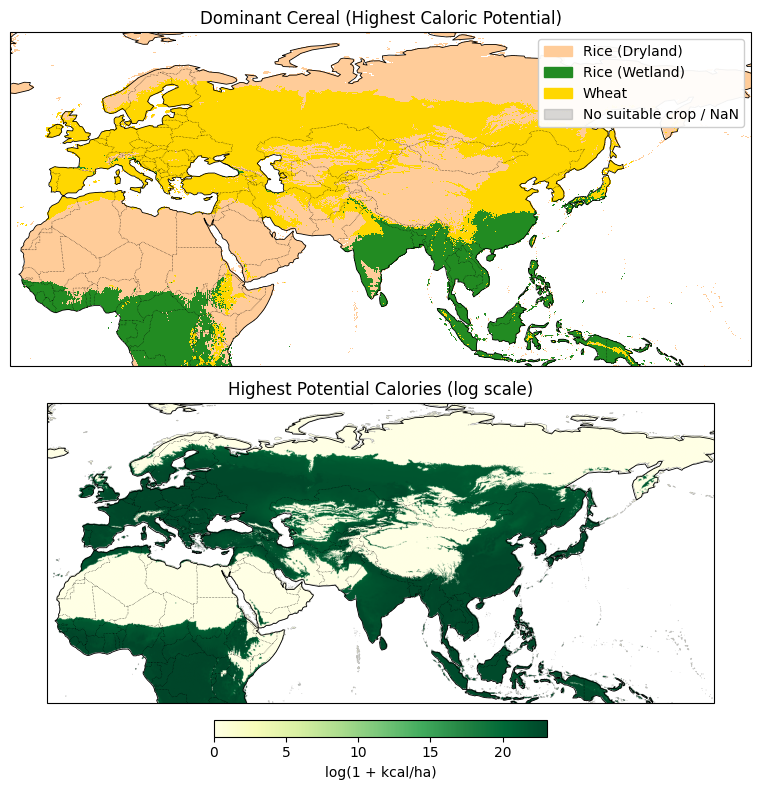

In [58]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ────────────────────────────────────────────────
# Visualization maps

fig, axes = plt.subplots(2, 1, figsize=(20, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# ────────────── Dominant Cereal Map ──────────────

axes[0].set_title('Dominant Cereal (Highest Caloric Potential)')

colors = ['#FFCC99',   # Rice Dryland
          '#228B22',   # Rice Wetland
          '#FFD700']   # Wheat

cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]          # boundaries around 0,1,2
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot with discrete colormap + norm
im0 = axes[0].imshow(dominant, 
                     cmap=cmap, 
                     norm=norm,
                     extent=(transform[2], transform[2] + transform[0]*dominant.shape[1],
                             transform[5] + transform[4]*dominant.shape[0], transform[5]),
                     transform=ccrs.PlateCarree(),
                     interpolation='nearest')  # avoids blurry edges

axes[0].add_feature(cfeature.COASTLINE, lw=0.6)
axes[0].add_feature(cfeature.BORDERS, linestyle=':', lw=0.4)

# Custom legend with crop names
legend_elements = [
    mpatches.Patch(color=colors[0], label='Rice (Dryland)'),
    mpatches.Patch(color=colors[1], label='Rice (Wetland)'),
    mpatches.Patch(color=colors[2], label='Wheat'),
    mpatches.Patch(color='gray', alpha=0.3, label='No suitable crop / NaN')
]

axes[0].legend(handles=legend_elements, 
               loc='upper right', 
               bbox_to_anchor=(1.0, 1.0), 
               fontsize=10,
               framealpha=0.95)


# ────────────── Highest Calories Map ──────────────

kcal_log = np.log1p(kcal_max)  # log(1 + x) for better contrast

axes[1].set_title('Highest Potential Calories (log scale)')
im1 = axes[1].imshow(kcal_log,
                     cmap='YlGn',
                     extent=(transform[2], transform[2] + transform[0]*kcal_log.shape[1],
                             transform[5] + transform[4]*kcal_log.shape[0], transform[5]),
                     transform=ccrs.PlateCarree(),
                     vmin=np.nanmin(kcal_log),
                     vmax=np.nanpercentile(kcal_log, 99))
axes[1].add_feature(cfeature.COASTLINE, lw=0.6)
axes[1].add_feature(cfeature.BORDERS, linestyle=':', lw=0.4)

cbar1 = fig.colorbar(im1, ax=axes[1], orientation='horizontal', 
                     fraction=0.05, pad=0.05, shrink=0.7)
cbar1.set_label('log(1 + kcal/ha)')

# Focus on Eurasia (Fractured-Land relevant region)
for ax in axes:
    ax.set_extent([-20, 180, -10, 80], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.savefig('cereal_maps_eurasia_fixed_legend.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# ────────────────────────────────────────────────
# Parameters
hex_side_m = 100000          # meters (~100 km)
dst_crs = 'EPSG:54009'      # Mollweide equal-area
src_crs = crs               # from earlier (EPSG:4326)

# Eurasia bounding box in lat/lon (for filtering valid hexes)
eurasia_bbox = (-20, 180, -10, 80)  # min_lon, max_lon, min_lat, max_lat

# ────────────────────────────────────────────────
# Reproject kcal_max to equal-area (same as before)
height, width = kcal_max.shape
dst_transform, dst_width, dst_height = calculate_default_transform(
    src_crs, dst_crs, width, height, *rasterio.transform.array_bounds(height, width, transform)
)

kcal_proj = np.empty((dst_height, dst_width), dtype=np.float32)
reproject(
    source=kcal_max,
    destination=kcal_proj,
    src_transform=transform,
    src_crs=src_crs,
    dst_transform=dst_transform,
    dst_crs=dst_crs,
    resampling=Resampling.bilinear
)
kcal_proj[np.isnan(kcal_proj)] = np.nan

print(f"Reprojected raster: {dst_width}×{dst_height}")

# ────────────────────────────────────────────────
# Generate hex centers (projected)
affine_proj = dst_transform
left, bottom, right, top = rasterio.transform.array_bounds(dst_height, dst_width, affine_proj)

dx = hex_side_m * np.sqrt(3)
dy = hex_side_m * 1.5

centers = []
x = left
row_idx = 0
while x < right:
    y_offset = dy / 2 if row_idx % 2 == 1 else 0
    y = bottom + y_offset
    while y < top:
        centers.append((x, y))
        y += dy
    x += dx
    row_idx += 1

centers = np.array(centers)
print(f"Generated {len(centers):,} hex centers")

# ────────────────────────────────────────────────
# Assign pixels to hexes and compute means (same as before)
rows, cols = np.mgrid[0:dst_height, 0:dst_width]
xs, ys = rasterio.transform.xy(affine_proj, rows, cols)
pixel_points = np.column_stack((xs.ravel(), ys.ravel()))
pixel_values = kcal_proj.ravel()

valid = ~np.isnan(pixel_values)
pixel_points = pixel_points[valid]
pixel_values = pixel_values[valid]

tree = KDTree(centers)
_, hex_ids = tree.query(pixel_points)

df = pd.DataFrame({'hex_id': hex_ids, 'kcal_ha': pixel_values})
hex_stats = df.groupby('hex_id')['kcal_ha'].agg(['mean', 'count']).reset_index()
hex_stats = hex_stats.rename(columns={'mean': 'y_mean_kcal_ha'})

# Merge centers
hex_centers_df = pd.DataFrame({
    'hex_id': range(len(centers)),
    'proj_x': centers[:, 0],
    'proj_y': centers[:, 1]
})
hex_stats = hex_stats.merge(hex_centers_df, on='hex_id', how='left')

# ────────────────────────────────────────────────
# Filter to Eurasia-like region (avoid reprojection errors)
# First, transform only the centers we care about
valid_hexes = []
lon_lat_list = []

for idx, row in hex_stats.iterrows():
    px, py = row['proj_x'], row['proj_y']
    try:
        lon, lat = rasterio.warp.transform(dst_crs, src_crs, [px], [py])
        lon, lat = lon[0], lat[0]
        if (eurasia_bbox[0] <= lon <= eurasia_bbox[1] and
            eurasia_bbox[2] <= lat <= eurasia_bbox[3]):
            valid_hexes.append(row)
            lon_lat_list.append((lon, lat))
    except Exception as e:
        # Skip hexes that cause reprojection domain errors
        continue

if not valid_hexes:
    raise ValueError("No hexes found within Eurasia bounds after filtering")

hex_stats_filtered = pd.DataFrame(valid_hexes)
hex_stats_filtered[['lon', 'lat']] = lon_lat_list

print(f"Filtered to {len(hex_stats_filtered)} hexes in Eurasia bounds")

# Save
hex_stats_filtered.to_csv('hex_caloric_productivity_eurasia.csv', index=False)

Reprojected raster: 9656×4830
Generated 25,185 hex centers
Filtered to 3872 hexes in Eurasia bounds


Created 3872 hexagon polygons in CRS: ESRI:54009


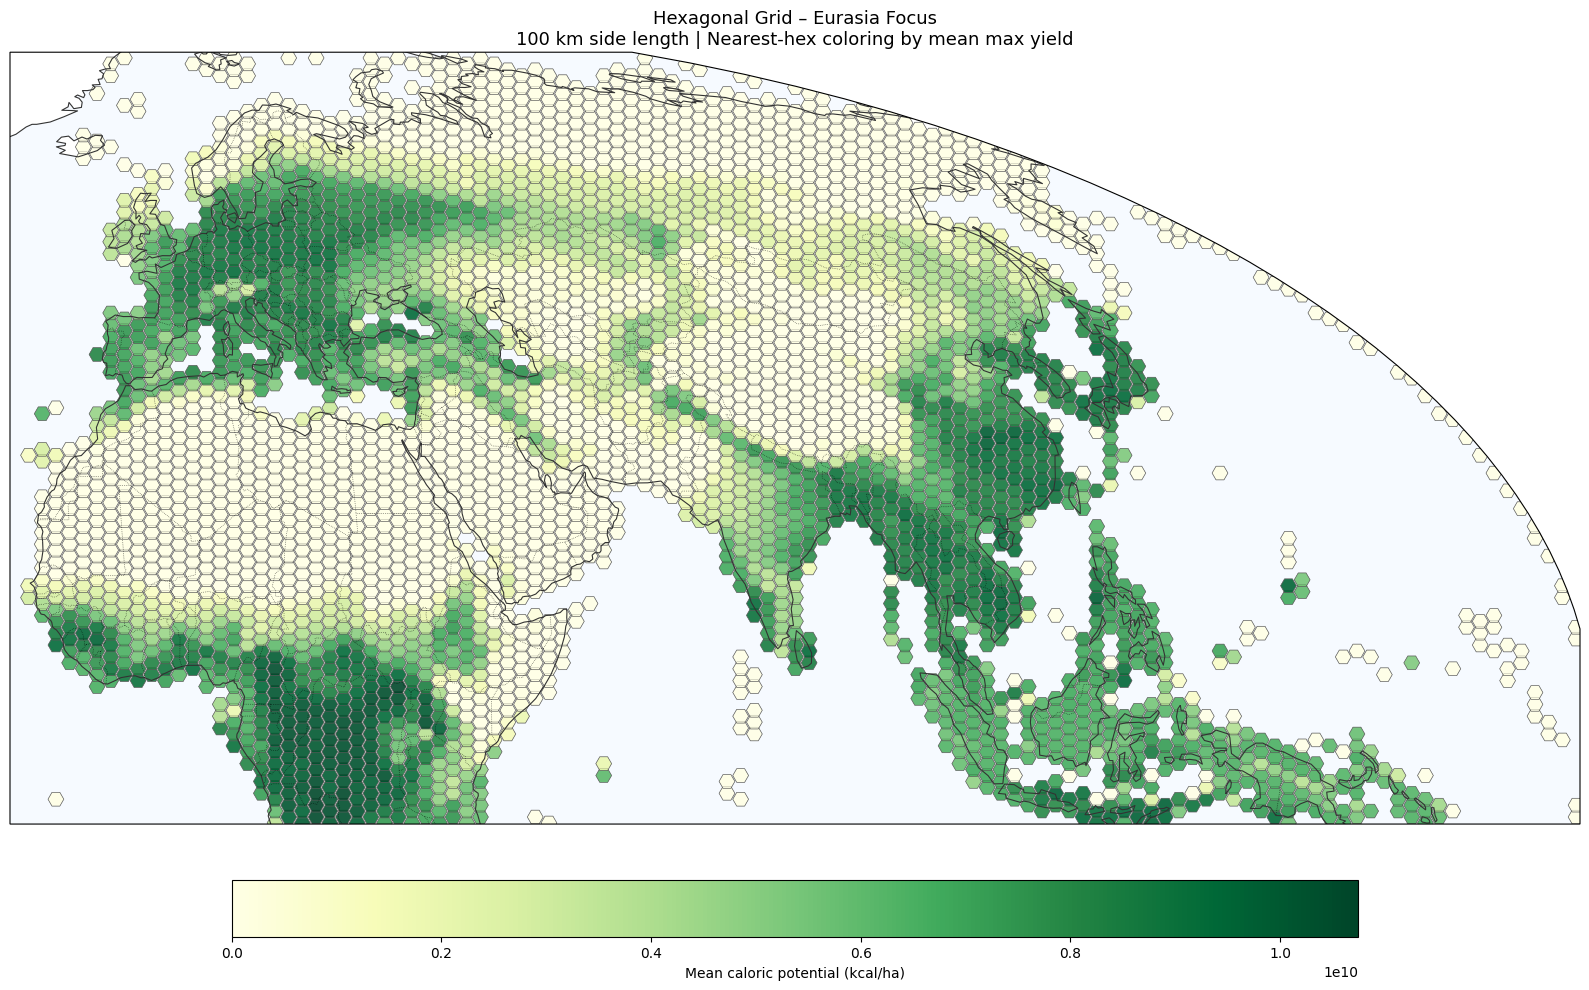

In [61]:
import geopandas as gpd
import shapely.geometry as sg
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Use correct authority code
dst_crs = "ESRI:54009"

# Create hexagon polygons
hex_polygons = []
for idx, row in hex_stats_filtered.iterrows():
    cx, cy = row['proj_x'], row['proj_y']
    
    # Regular hexagon vertices (flat-top orientation)
    angles = np.linspace(0, 2 * np.pi, 7)  # 6 + closing point
    vertices = [(cx + hex_side_m * np.cos(a), cy + hex_side_m * np.sin(a)) for a in angles]
    
    poly = sg.Polygon(vertices)
    hex_polygons.append({
        'geometry': poly,
        'y_kcal': row['y_mean_kcal_ha'],
        'hex_id': idx
    })

# GeoDataFrame with correct CRS
gdf_hex = gpd.GeoDataFrame(hex_polygons, crs=dst_crs)

print(f"Created {len(gdf_hex)} hexagon polygons in CRS: {gdf_hex.crs}")

# ────────────────────────────────────────────────
# Plotting

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

# Colormap & normalization
cmap = 'YlGn'
norm = mcolors.Normalize(
    vmin=hex_stats_filtered['y_mean_kcal_ha'].min(),
    vmax=hex_stats_filtered['y_mean_kcal_ha'].max()
)

# Plot hexagons → fills the map with nearest-hex color
gdf_hex.plot(
    ax=ax,
    column='y_kcal',
    cmap=cmap,
    norm=norm,
    edgecolor='0.4',
    linewidth=0.5,
    alpha=0.9,
    transform=ccrs.Mollweide(),
    legend=True,
    legend_kwds={
        'label': "Mean caloric potential (kcal/ha)",
        'orientation': "horizontal",
        'shrink': 0.75,
        'pad': 0.05,
        'fraction': 0.05,
        'anchor': (0.5, -0.1)
    }
)

# Optional: thicker border lines
gdf_hex.boundary.plot(
    ax=ax,
    color='0.2',
    linewidth=0.1,
    transform=ccrs.Mollweide()
)

# Context layers
ax.add_feature(cfeature.COASTLINE, lw=0.8, edgecolor='0.2')
ax.add_feature(cfeature.BORDERS, lw=0.5, linestyle=':', alpha=0.7)
ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff', alpha=0.35)

# Eurasia focus
ax.set_extent([-20, 180, -10, 80], crs=ccrs.PlateCarree())

ax.set_title(f"Hexagonal Grid – Eurasia Focus\n"
             f"{hex_side_m/1000:.0f} km side length | Nearest-hex coloring by mean max yield",
             fontsize=13)

plt.tight_layout()
plt.savefig('hex_grid_full_color_eurasia.png', dpi=180, bbox_inches='tight')
plt.show()

Filter out Sea Hexes